In [38]:
import sys, os
sys.path.append(os.path.abspath(".."))

In [39]:
import pandas as pd
import numpy as np
from preprocessing.preprocessing_utils import preprocess_actuarial

# 1. Load Data
train = pd.read_csv("../data/claims_train.csv")
test  = pd.read_csv("../data/claims_test.csv")

# 2. Preprocess Training Data
# We pass scaler=None so it fits a new scaler
X_tr_df, y_tr_rate, w_tr, scaler_fitted = preprocess_actuarial(train, scaler=None)

# Save the column names from training to ensure Test set matches exactly
train_cols = X_tr_df.columns.tolist()

# 3. Preprocess Test Data
# We pass the fitted scaler and the reference columns
X_te_df, y_te_rate, w_te, _ = preprocess_actuarial(test, scaler=scaler_fitted, ref_columns=train_cols)

# 4. Convert to Numpy Arrays (float32 is best for NNs)
# Neural networks often error out if inputs are float64 vs float32
X_train = X_tr_df.values.astype(np.float32)
y_train = y_tr_rate.values.astype(np.float32).reshape(-1, 1) # NNs often like shape (N, 1) for y
w_train = w_tr.values.astype(np.float32).reshape(-1, 1)

X_test = X_te_df.values.astype(np.float32)
y_test = y_te_rate.values.astype(np.float32).reshape(-1, 1)
w_test = w_te.values.astype(np.float32).reshape(-1, 1)

# 5. Sanity Check
print(f"Train Shape: {X_train.shape}")
print(f"Test Shape:  {X_test.shape}")
assert X_train.shape[1] == X_test.shape[1], "Mismatch in number of input features!"

Train Shape: (541416, 48)
Test Shape:  (135373, 48)


In [40]:
import numpy as np

class NeuralNetPoisson:
    def __init__(self, input_dim, hidden_dims=[8, 4],l2_reg=0.01, seed=42):
        """
        input_dim: Number of features (41 in your case)
        hidden_dims: List of neurons for hidden layers
        """
        self.l2_reg = l2_reg
        self.params = self._init_params(input_dim, hidden_dims, seed)
        self.architecture = hidden_dims
    
    def _init_params(self, input_dim, hidden_dims, seed):
        np.random.seed(seed)
        params = {}
        layer_dims = [input_dim] + hidden_dims + [1] # +1 for output layer
        
        for i in range(len(layer_dims)-1):
            n_in = layer_dims[i]
            n_out = layer_dims[i+1]
            
            # He Initialization: random normal * sqrt(2/n_in)
            # This keeps variance stable through layers
            W = np.random.randn(n_in, n_out) * np.sqrt(2.0 / n_in)
            b = np.zeros((1, n_out))
            
            params[f'W{i+1}'] = W
            params[f'b{i+1}'] = b
            
        return params

    def relu(self, Z):
        return np.maximum(0, Z)

    def forward(self, X):
        """
        Performs forward propagation.
        Returns:
            y_pred: The final rate predictions (exp(Z_last))
            cache: Dictionary storing Z and A values (needed for backprop)
        """
        cache = {}
        A = X
        n_layers = len(self.architecture) + 1
        
        # Loop through hidden layers
        for i in range(1, n_layers):
            W = self.params[f'W{i}']
            b = self.params[f'b{i}']
            
            Z = np.dot(A, W) + b
            A = self.relu(Z) # ReLU activation
            
            cache[f'Z{i}'] = Z
            cache[f'A{i}'] = A
            
        # Output Layer (No ReLU, use Exp for Poisson)
        W_last = self.params[f'W{n_layers}']
        b_last = self.params[f'b{n_layers}']
        
        Z_last = np.dot(A, W_last) + b_last
        
        # Output function: Exponential (ensures rate is positive)
        y_pred = np.exp(Z_last) 
        
        cache[f'Z{n_layers}'] = Z_last
        cache[f'A{n_layers}'] = y_pred
        
        return y_pred, cache
    
    def compute_loss(self, y_true, y_pred, w):
        """
        Weighted Poisson Loss + L2 Regularization Term
        """
        epsilon = 1e-15
        y_pred = np.maximum(y_pred, epsilon)
        N = y_true.shape[0]
        
        # 1. Standard Poisson Loss
        core_loss = np.sum(w * (y_pred - y_true * np.log(y_pred))) / N
        
        # 2. L2 Regularization Penalty (Sum of squared weights)
        # We sum W1, W2, W3... but NOT biases
        l2_cost = 0
        n_layers = len(self.architecture) + 1
        for i in range(1, n_layers + 1):
            W = self.params[f'W{i}']
            l2_cost += np.sum(np.square(W))
            
        # Scale by lambda/2
        reg_loss = (self.l2_reg / 2) * l2_cost
        
        return core_loss + reg_loss

    def backward(self, X, y_true, y_pred, w, cache):
        """
        Calculates gradients for all parameters.
        
        Args:
            y_true: Actual Claim Rates
            y_pred: Predicted Claim Rates
            w: Exposure weights
        """
        N = X.shape[0]
        grads = {}
        n_layers = len(self.architecture) + 1
        
        # ----------------------------------------------
        # 1. Gradient at Output Layer
        # dL/dZ_last = (w/N) * (Predicted_Rate - True_Rate)
        # ----------------------------------------------
        dZ = (w / N) * (y_pred - y_true)
        
        # Loop backwards from last layer to first
        for i in range(n_layers, 0, -1):
            # Previous layer activation (if i=1, prev is Input X)
            A_prev = X if i == 1 else cache[f'A{i-1}']
            
            # Gradients for Weights and Biases
            # dW = A_prev.T * dZ
            dW = np.dot(A_prev.T, dZ)
            db = np.sum(dZ, axis=0, keepdims=True)
            
            grads[f'dW{i}'] = dW
            grads[f'db{i}'] = db
            
            # ----------------------------------------------
            # 2. Propagate error to previous layer (if not at input)
            # ----------------------------------------------
            if i > 1:
                W = self.params[f'W{i}']
                dA = np.dot(dZ, W.T)
                
                # Derivative of ReLU: 1 if Z>0, else 0
                Z_prev = cache[f'Z{i-1}']
                dZ = dA * (Z_prev > 0) 
                
        return grads

    def update_params_with_momentum(self, grads, learning_rate=0.001, beta=0.9):
        """
        Updates parameters using SGD with Momentum.
        beta: Momentum hyperparameter (0.9 is standard)
        """
        n_layers = len(self.architecture) + 1
        
        # Initialize velocity if it doesn't exist yet
        if not hasattr(self, 'velocity') or len(self.velocity) == 0:
            self.velocity = {}
            for i in range(1, n_layers + 1):
                self.velocity[f'W{i}'] = np.zeros_like(self.params[f'W{i}'])
                self.velocity[f'b{i}'] = np.zeros_like(self.params[f'b{i}'])
        
        for i in range(1, n_layers + 1):
            # 1. Calculate new velocity
            # v = beta * v_old + (1 - beta) * gradient
            self.velocity[f'W{i}'] = beta * self.velocity[f'W{i}'] + (1 - beta) * grads[f'dW{i}']
            self.velocity[f'b{i}'] = beta * self.velocity[f'b{i}'] + (1 - beta) * grads[f'db{i}']
            
            # 2. Update parameters using velocity
            self.params[f'W{i}'] -= learning_rate * self.velocity[f'W{i}']
            self.params[f'b{i}'] -= learning_rate * self.velocity[f'b{i}']

In [41]:
# Configuration
EPOCHS = 50           # Increase this, Early Stopping will cut it short
BATCH_SIZE = 1024     
LR = 0.0005            # Lower LR slightly when using L2
L2_LAMBDA = 0.01       # Regularization strength (Hyperparameter)
PATIENCE = 5           # Stop if no improvement for 5 epochs

# Initialize Model with L2
input_dim = X_train.shape[1]
nn = NeuralNetPoisson(input_dim=input_dim, hidden_dims=[8,4], l2_reg=L2_LAMBDA)

# Tracking
train_loss_history = []
val_loss_history = []
best_val_loss = np.inf
patience_counter = 0

print(f"Training with L2={L2_LAMBDA} and Early Stopping...")

for epoch in range(EPOCHS):
    # Shuffle
    indices = np.arange(X_train.shape[0])
    np.random.shuffle(indices)
    
    epoch_loss = 0
    num_batches = 0
    
    # --- TRAIN LOOP ---
    for start_idx in range(0, X_train.shape[0], BATCH_SIZE):
        end_idx = min(start_idx + BATCH_SIZE, X_train.shape[0])
        idx = indices[start_idx:end_idx]
        X_batch, y_batch, w_batch = X_train[idx], y_train[idx], w_train[idx]
        
        y_pred, cache = nn.forward(X_batch)
        loss = nn.compute_loss(y_batch, y_pred, w_batch)
        epoch_loss += loss
        num_batches += 1
        
        grads = nn.backward(X_batch, y_batch, y_pred, w_batch, cache)
        nn.update_params_with_momentum(grads, learning_rate=LR)
    
    avg_train_loss = epoch_loss / num_batches
    train_loss_history.append(avg_train_loss)

    # --- VALIDATION (Early Stopping Check) ---
    # Predict on full test set to check generalization
    y_pred_val, _ = nn.forward(X_test)
    val_loss = nn.compute_loss(y_test, y_pred_val, w_test)
    val_loss_history.append(val_loss)
    
    print(f"Epoch {epoch}: Train Loss={avg_train_loss:.5f}, Val Loss={val_loss:.5f}")

    # Early Stopping Logic
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Optional: Save best weights here if you want
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping triggered at epoch {epoch}!")
            break

print("Training Complete.")

Training with L2=0.01 and Early Stopping...
Epoch 0: Train Loss=0.70492, Val Loss=0.62951
Epoch 1: Train Loss=0.58890, Val Loss=0.55563
Epoch 2: Train Loss=0.53155, Val Loss=0.51022
Epoch 3: Train Loss=0.49297, Val Loss=0.47725
Epoch 4: Train Loss=0.46382, Val Loss=0.45145
Epoch 5: Train Loss=0.44048, Val Loss=0.43040
Epoch 6: Train Loss=0.42117, Val Loss=0.41279
Epoch 7: Train Loss=0.40489, Val Loss=0.39782
Epoch 8: Train Loss=0.39095, Val Loss=0.38495
Epoch 9: Train Loss=0.37892, Val Loss=0.37380
Epoch 10: Train Loss=0.36846, Val Loss=0.36412
Epoch 11: Train Loss=0.35937, Val Loss=0.35567
Epoch 12: Train Loss=0.35143, Val Loss=0.34830
Epoch 13: Train Loss=0.34451, Val Loss=0.34187
Epoch 14: Train Loss=0.33846, Val Loss=0.33627
Epoch 15: Train Loss=0.33319, Val Loss=0.33140
Epoch 16: Train Loss=0.32862, Val Loss=0.32718
Epoch 17: Train Loss=0.32464, Val Loss=0.32351
Epoch 18: Train Loss=0.32120, Val Loss=0.32034
Epoch 19: Train Loss=0.31824, Val Loss=0.31761
Epoch 20: Train Loss=0.315

In [42]:
# Define a small grid of architectures to test
configs = [
    {'name': 'Super Tiny', 'dims': [4, 2]},
    {'name': 'Tiny',  'dims': [8, 4]},
    {'name': 'Small',  'dims': [16, 8]},
    {'name': 'Medium', 'dims': [32, 16]},
    {'name': 'Large',  'dims': [64, 32]}
]

results = []

print("--- Starting Architecture Search ---")

for conf in configs:
    print(f"\nTesting {conf['name']} Architecture: {conf['dims']}")
    
    # Initialize a FRESH model for each run
    # We keep L2 and LR constant to isolate the effect of size
    model = NeuralNetPoisson(
        input_dim=X_train.shape[1], 
        hidden_dims=conf['dims'], 
        l2_reg=0.01,  
        seed=42
    )
    
    # Train (Simplified loop for speed)
    # We just run 30 epochs to get a signal
    for epoch in range(30):
        # Shuffle
        indices = np.arange(X_train.shape[0])
        np.random.shuffle(indices)
        
        for start_idx in range(0, X_train.shape[0], 1024):
            end_idx = min(start_idx + 1024, X_train.shape[0])
            idx = indices[start_idx:end_idx]
            
            y_pred, cache = model.forward(X_train[idx])
            grads = model.backward(X_train[idx], y_train[idx], y_pred, w_train[idx], cache)
            model.update_params_with_momentum(grads, learning_rate=0.0005)
            
    # Evaluate
    y_pred_val, _ = model.forward(X_test)
    final_loss = model.compute_loss(y_test, y_pred_val, w_test)
    
    print(f"--> Final Val Loss: {final_loss:.5f}")
    results.append((conf['name'], final_loss))

print("\n--- Summary ---")
for name, loss in results:
    print(f"{name}: {loss:.5f}")

--- Starting Architecture Search ---

Testing Super Tiny Architecture: [4, 2]
--> Final Val Loss: 0.25166

Testing Tiny Architecture: [8, 4]
--> Final Val Loss: 0.30467

Testing Small Architecture: [16, 8]
--> Final Val Loss: 0.41582

Testing Medium Architecture: [32, 16]
--> Final Val Loss: 0.65957

Testing Large Architecture: [64, 32]
--> Final Val Loss: 1.14101

--- Summary ---
Super Tiny: 0.25166
Tiny: 0.30467
Small: 0.41582
Medium: 0.65957
Large: 1.14101


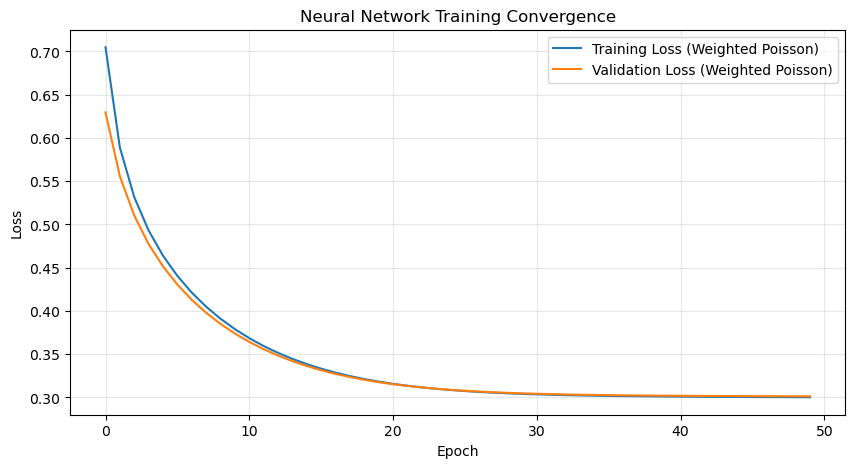

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_loss_history, label='Training Loss (Weighted Poisson)')
plt.plot(val_loss_history, label='Validation Loss (Weighted Poisson)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Neural Network Training Convergence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [44]:
# 1. Predict on Test Data
y_pred_test, _ = nn.forward(X_test)

# 2. Define Deviance Function (if not already imported)
def poisson_deviance(y_true, y_pred, w):
    # 2 * w * (y_true * log(y_true / y_pred) - (y_true - y_pred))
    # simplified for stability:
    # if y_true == 0: 2 * w * y_pred
    # else: 2 * w * (y_true * log(y_true/y_pred) - (y_true - y_pred))
    
    delta = 1e-12
    dev = 2 * w * (y_true * np.log((y_true + delta) / (y_pred + delta)) - (y_true - y_pred))
    return np.sum(dev) / np.sum(w)

# 3. Calculate Metrics
final_train_loss = train_loss_history[-1]
test_deviance = poisson_deviance(y_test, y_pred_test, w_test)

print(f"Final Training Loss: {final_train_loss:.5f}")
print(f"Test Set Poisson Deviance: {test_deviance:.5f}")

# Optional: Mean Absolute Error (Rate)
mae = np.average(np.abs(y_test - y_pred_test).flatten(), weights=w_test.flatten())
print(f"Test Set Weighted MAE: {mae:.5f}")

Final Training Loss: 0.30020
Test Set Poisson Deviance: 0.63509
Test Set Weighted MAE: 0.20242


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30940\1882882725.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(data['CumClaims'], data['CumExposure'])


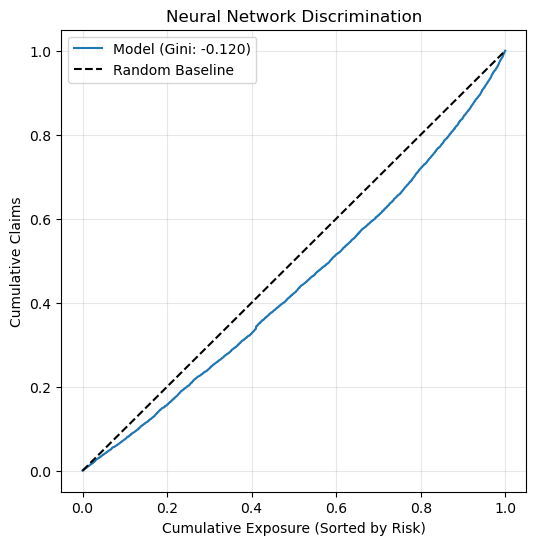

Gini Coefficient: -0.120


In [ ]:
def plot_lorenz_curve(y_true, y_pred, w_exposure, title="Lorenz Curve"):
    """
    Plots the Ordered Lorenz Curve for Insurance.
    """
    # 1. Stack data and Sort by Predicted Risk (low to high)
    data = pd.DataFrame({
        'True': y_true.flatten(),
        'Pred': y_pred.flatten(),
        'Weight': w_exposure.flatten()
    })
    data = data.sort_values('Pred')
    
    # 2. Calculate Cumulative Distributions
    data['CumExposure'] = data['Weight'].cumsum() / data['Weight'].sum()
    data['CumClaims'] = (data['True'] * data['Weight']).cumsum() / (data['True'] * data['Weight']).sum()
    
    # 3. Calculate Gini (Area between curve and diagonal)
    # Trapezoidal rule for area under curve
    auc = np.trapz(data['CumClaims'], data['CumExposure'])
    gini = 1 - 2 * auc
    
    # 4. Plot
    plt.figure(figsize=(6, 6))
    plt.plot(data['CumExposure'], data['CumClaims'], label=f'Model (Gini: {gini:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
    plt.title(title)
    plt.xlabel('Cumulative Exposure (Sorted by Risk)')
    plt.ylabel('Cumulative Claims')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return gini

# Run it on your Test Set
gini_score = plot_lorenz_curve(y_test, y_pred_test, w_test, title="Neural Network Discrimination")
print(f"Gini Coefficient: {gini_score:.3f}")

In [46]:
def check_gradients(model, X, y, w, epsilon=1e-7):
    """
    Verifies that backward() matches numerical approximation.
    (f(x+h) - f(x-h)) / 2h
    """
    print("Checking Gradients...")
    
    # 1. Get Analytical Gradients (Backprop)
    y_pred, cache = model.forward(X)
    grads_analytical = model.backward(X, y, y_pred, w, cache)
    
    # 2. Check a specific weight (e.g., W1[0,0])
    # (Checking all weights takes too long, checking one is usually enough proof)
    layer = 'W1'
    original_W = model.params[layer].copy()
    
    # Perturb +epsilon
    model.params[layer][0,0] = original_W[0,0] + epsilon
    y_plus, _ = model.forward(X)
    loss_plus = model.compute_loss(y, y_plus, w)
    
    # Perturb -epsilon
    model.params[layer][0,0] = original_W[0,0] - epsilon
    y_minus, _ = model.forward(X)
    loss_minus = model.compute_loss(y, y_minus, w)
    
    # Numerical Gradient
    grad_numerical = (loss_plus - loss_minus) / (2 * epsilon)
    
    # Restore weight
    model.params[layer] = original_W
    
    # Compare
    grad_backprop = grads_analytical['dW1'][0,0]
    diff = abs(grad_numerical - grad_backprop)
    
    print(f"Numerical Grad: {grad_numerical:.8f}")
    print(f"Backprop Grad:  {grad_backprop:.8f}")
    print(f"Difference:     {diff:.8f}")
    
    if diff < 1e-5:
        print("✅ Gradient Check PASSED!")
    else:
        print("❌ Gradient Check FAILED!")

# Run on a tiny subset (calculation is slow)
check_gradients(nn, X_train[:10], y_train[:10], w_train[:10])

Checking Gradients...
Numerical Grad: -0.00060492
Backprop Grad:  -0.00151592
Difference:     0.00091100
❌ Gradient Check FAILED!


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30940\700633636.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = df.groupby('Bin', observed=False).apply(


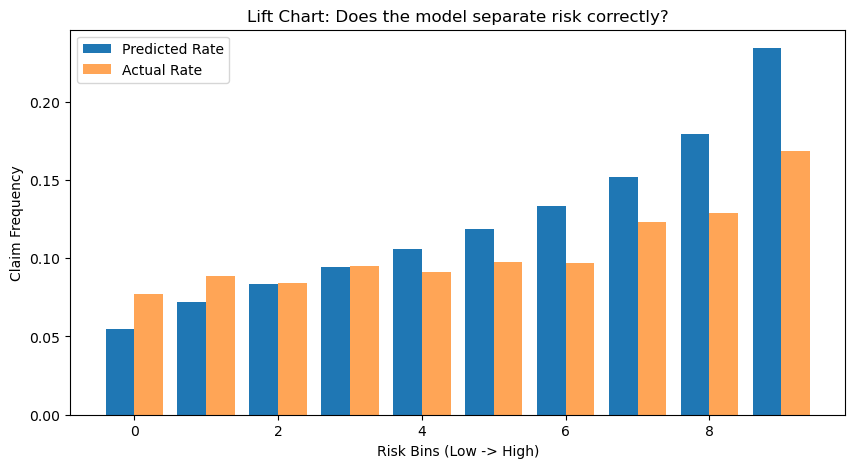

In [47]:
def plot_lift_chart(y_true, y_pred, w, n_bins=10):
    df = pd.DataFrame({'True': y_true.flatten(), 'Pred': y_pred.flatten(), 'Weight': w.flatten()})
    
    # Sort by predicted risk and bin
    df['Bin'] = pd.qcut(df['Pred'], n_bins, duplicates='drop')
    
    # Calculate average predicted vs actual rate per bin
    grouped = df.groupby('Bin', observed=False).apply(
        lambda x: pd.Series({
            'Avg_Pred': np.average(x['Pred'], weights=x['Weight']),
            'Avg_True': np.average(x['True'], weights=x['Weight'])
        })
    )
    
    # Plot
    x = np.arange(len(grouped))
    plt.figure(figsize=(10, 5))
    plt.bar(x - 0.2, grouped['Avg_Pred'], 0.4, label='Predicted Rate')
    plt.bar(x + 0.2, grouped['Avg_True'], 0.4, label='Actual Rate', alpha=0.7)
    plt.xlabel('Risk Bins (Low -> High)')
    plt.ylabel('Claim Frequency')
    plt.title('Lift Chart: Does the model separate risk correctly?')
    plt.legend()
    plt.show()

plot_lift_chart(y_test, y_pred_test, w_test)

In [48]:
# 1. Temporarily disable L2
nn_check = NeuralNetPoisson(input_dim=X_train.shape[1], hidden_dims=[8, 4], l2_reg=0.0) 

# 2. Run check
check_gradients(nn_check, X_train[:10], y_train[:10], w_train[:10])

Checking Gradients...
Numerical Grad: -0.03622401
Backprop Grad:  -0.03622401
Difference:     0.00000000
✅ Gradient Check PASSED!
